We can start with the same dependencies as in the previous notebooks.

In [61]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt

Create the same dataset from the previous notebooks.

In [ ]:
words = open("names.txt", "r").read().splitlines()
chars = sorted(list(set("".join(words))))

s_i = {s:i+1 for i, s in enumerate(chars)}
s_i["."] = 0

i_s = {i:s for s, i in s_i.items()}

# building dataset

block_size = 3

def build_dataset(words):
    
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        
        for ch in w + ".":
            ix = s_i[ch]
            X.append(context)
            Y.append(ix)
            # print("".join(i_s[i] for i in context), "---->", i_s[ix])
            context = context[1:] + [ix]
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

Create training, validation, and test sets, as in the previous notebook.

In [63]:
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

We implement a PyTorch-like API, as seen in notebook #3, but with additional functionality.

**Layer classes**
- `Linear`: linear layer that takes an input vector, applies weights and biases, then produces an output vector
    - `fan_in`: # of inputs
    - `fan_out`: # of neurons in layer; also number of outputs
    - `bias`: whether or not the layer should apply a bias

- `BatchNorm1D`: batch normalization layer, as seen in notebook #3 (see [`3_batch_norm.ipynb`](3_batch_norm.ipynb) for more details)
    - `dim`: size of input vector
    - `eps`: constant added for numerical stability when variance is extremely small or zero
    - `momentum`: value used to calculate the running mean during model training

- `Tanh`: non-linearity layer, as seen in [Bengio et al. 2003](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)
    - `x`: input vector

- `Embedding`: creates a lookup table for mapping tokens, which are characters in our case
    - `n_embd`: # of tokens we want to embed
    - `emb_dim`: # of dimensions in the feature space containing the tokens

- `FlattenConsecutive`: flatten layer used for the WaveNet implementation in our model; slowly crushes the information in the training set, rather than crushing it all at once, thus making our model perform much better
    - `n`: input vector

**Finally, we have the `Sequential` class:**
- `Sequential`: stores a sequential array of layers, allowing us to combine them into a model
    - `layers`: array of the desired layers for the model
    - `__call__()`: passes an input vector into the first layer, through the hidden layers, and outputs the product of the final layer
    - `train()`: API-like implementation of the training loop in the previous notebooks
    - `zero_grad()`: helper function for setting the gradients of all the model's parameters to `0`; used during the training loop

In [ ]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.randn(fan_out) * 0.1 if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        
        if self.bias is not None:
            self.out += self.bias
            
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.001):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        
        # parameters
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        
        # buffers (trained by momentum update)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
        
    def __call__(self, x):
        # forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
                
            xmean = x.mean(dim, keepdim=True) # batch mean
            xvar = x.var(dim, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        
        # update buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        
        return self.out
        
    def parameters(self):
        return []
    
class Embedding:
    def __init__(self, n_emb, emb_dim):
        self.weight = torch.randn((n_emb, emb_dim))
    
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n
    
    def __call__(self, x):
        B, T, C, = x.shape
        x = x.view(B, T // self.n, C * self.n)
        
        if x.shape[1] == 1:
            x = x.squeeze(1)
            
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    
class Sequential:
    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        
        self.out = x
        return self.out
    
    def fit(self, max_steps, x, y, batch_size=32, lr=0.1, generator=torch.Generator().manual_seed(2147483647)):
        lossi = []
        
        for i in range(max_steps):
            # make mini batches
            ix = torch.randint(0, x.shape[0], (batch_size,), generator=generator)
            Xb, Yb = x[ix], y[ix]
            
            logits = self(Xb)
            
            loss = F.cross_entropy(logits, Yb)
            
            self.zero_grad()
                
            loss.backward()
            
            # update
            learn_rate = lr if i < max_steps / 2 else lr / 10
            for p in self.parameters():
                p.data += -learn_rate * p.grad
                
            # track stats  
            if i % (max_steps / 10) == 0:
                print(f"{i:7d}/{max_steps:7d}: {loss.item():4f}")

            lossi.append(loss.item())
        
        print(f"Final loss: {lossi[-1]:4f}")
        
        return lossi
        
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
    def zero_grad(self):
        for p in self.parameters():
            p.grad = None

In [113]:
torch.manual_seed(42);

In [ ]:
n_embd = 10 # dimensionality of character embedding vectors
n_hidden = 68 # neurons in hidden layer

g = torch.Generator().manual_seed(2147483647)

vocab_size = 27

# C = torch.randn((vocab_size, n_embd), generator=g)

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden,            vocab_size),
])

# make last layer less confident
with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print("Total parameters:", sum(p.nelement() for p in parameters)) # number of parameters

for p in parameters:
    p.requires_grad = True

Total parameters: 22397


Create some outputs for model examination purposes.

In [ ]:
ix = torch.randint(0, Xtr.shape[0], (4, ))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)

The cell below wouldn't work without the one above.

In [143]:
for layer in model.layers:
    print(layer.__class__.__name__, ":", tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


Train the model.

In [144]:
lossi = model.fit(max_steps=100000, x=Xtr, y=Ytr)

      0/ 100000: 3.287687
  10000/ 100000: 2.172488
  20000/ 100000: 2.163876
  30000/ 100000: 1.522365
  40000/ 100000: 2.228030
  50000/ 100000: 1.840600
  60000/ 100000: 2.121608
  70000/ 100000: 2.160707
  80000/ 100000: 2.234536
  90000/ 100000: 2.113824
Final loss: 1.776281


We can then use `matplotlib` to visualize the model's learning over time.

To smooth out the noise, we take group the iterations into batches of 1000 and calculate the average of each batch.

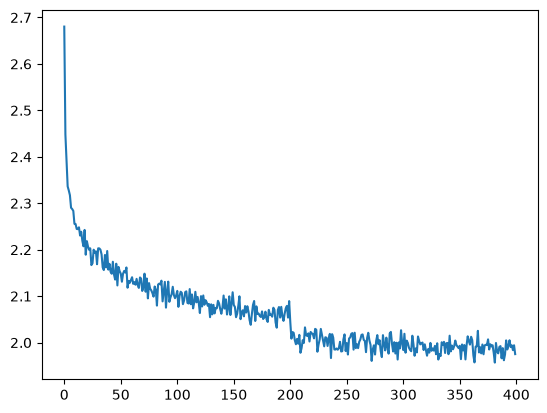

In [148]:
plt.plot(torch.tensor(lossi).view(-1, 250).mean(1))

Remember to turn off training mode so inference works correctly.

This simply adjusts how the batch normalization runs in the model.

In [150]:
for layer in model.layers:
    layer.training = False

We can then evaluate the model's performance on the training and validation sets.

Here, we see that the WaveNet architecture performs noticeably better than the MLP in notebook #3.

We also avoided overfitting, as seen by the small difference in performance between the two sets.

In [151]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
    }[split]
    
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    
    print(split, loss.item())
    
split_loss("train")
split_loss("dev")

train 1.9602130651474
dev 2.0332906246185303


Lastly, to run inference, we use roughly the same implementation as in the other notebooks.

In [152]:
g2 = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size

    while True:
        logits = model(torch.tensor([context]))

        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g2).item()

        context = context[1:] + [ix]
        if ix == 0:
            break
        out.append(ix)

    print("".join(i_s[i] for i in out))

carlah
amilli
khylm
shreet
khalan
kenleh
braden
artiere
isara
kentzia
ivianna
greyli
join
quint
shovera
jadiquis
elogieary
izai
eveigs
brex


I found that this model performed significantly better than the one from notebook #3. 

```
carlah
amilli
khylm
shreet
khalan
kenleh
braden
artiere
isara
kentzia
ivianna
greyli
join
quint
shovera
jadiquis
elogieary
izai
eveigs
brex
```